In [1]:
import varray as va
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import ldax_processing as ldax
from scipy.optimize import curve_fit
from matplotlib import colors
import math
import processingFunctions
from tqdm import tqdm
from matplotlib.patches import Ellipse
plt.style.use('../style.mplstyle')

In [2]:
rq_path = '/mnt/drive2/TPC_RQs/proc_settings_amp50V_v004/'

dates = ['2026-09-14-0744,50']

rq_names = [
    'p_area',
    'p_area_ch',
    'p_height_ch',
    'p_nfold',
    'p_bnds',
    'p_aft',
    'p_class'
]

dataset_labels = [
    '2026-09-14-0744',
]

In [3]:
#Collect all data from selected files and store them in dict
d = processingFunctions.get_all_data(dates, dataset_labels, rq_path, rq_names)

Finished collecting data for 2026-09-14-0744


In [4]:
def plot2d(x, y, x_range=None, y_range=None, x_bins=50, y_bins=50, flag_log=False, flag_mask=True, cmap=None):
    if cmap is None:
        cmap = matplotlib.cm.viridis
    if not isinstance(cmap,type(matplotlib.cm.jet)) and \
        not isinstance(cmap,type(matplotlib.cm.plasma)):
        raise TypeError("input cmap must be a matplotlib color map object.")
    if x_range is None:
        x_range = [x.min(), x.max()]
    if y_range is None:
        y_range = [y.min(), y.max()]
    if (x_range[1]-x_range[0])<0:
        x_range = x_range[::-1]
    if (y_range[1]-y_range[0])<0:
        y_range = y_range[::-1]
    #**** </INPUT HANDLING> ****#
    
    # Make the bin edges
    x_xe = np.linspace(x_range[0], x_range[1], x_bins+1) # add 1 because these are bin edges
    x_ye = np.linspace(y_range[0], y_range[1], y_bins+1) # add 1 because these are bin edges
    x_width = np.abs(x_xe[1]-x_xe[0])
    y_width = np.abs(x_ye[1]-x_ye[0])
    
    # Calculate the 2-D histogram and flatten it
    n = np.histogramdd(np.array([x,y]).T, [x_xe, x_ye])[0]
    
    if flag_mask:
        n_max = n[n>0].max()
        n_min = n[n>0].min()
        n = np.ma.masked_where(n<=0, n)
    else:
        if flag_log:
            n[n<=0] = 0.1
        n_max = n.max()
        n_min = n.min()
    
    # Create a normalization function based on whether the user wants a lin or log color scale.
    if flag_log:
        n_Norm = matplotlib.colors.LogNorm(vmin=n_min, vmax=n_max)
    else:
        n_Norm = matplotlib.colors.Normalize(vmin=n_min, vmax=n_max)
    
    h = plt.pcolormesh(x_xe, x_ye, n.T, norm=n_Norm, cmap=cmap)
    h.set_edgecolor('face')
    h.set_linewidth(0.001)
    if flag_log and (not flag_mask):
        cMax = h.get_clim()[1]
        h.set_clim((.8,cMax))
    return n

In [5]:
p_class = np.asarray(d[dataset_labels[0]]['p_class'])
p_area_ch = np.asarray(d[dataset_labels[0]]['p_area_ch'])
p_height_ch = np.asarray(d[dataset_labels[0]]['p_height_ch'])

In [6]:
all_pulse_areas = {}
all_pulse_heights = {}

for i in tqdm(range(32)):
    all_pulse_areas[i] = p_area_ch[:,i,:][(p_class==3) & (p_area_ch[:,i,:] > 0)]
    all_pulse_heights[i] = p_height_ch[:,i,:][(p_class==3) & (p_area_ch[:,i,:] > 0)]

100%|██████████| 32/32 [00:00<00:00, 53.12it/s]


In [13]:
def gaussian(x, amplitude, mean, sigma):
    """
    Returns a standard Gaussian curve value for a given x.
    amplitude: peak height
    mean: center of the peak
    sigma: standard deviation (width)
    """
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

def get_spe_stats(lower_bound, upper_bound, i):
    bound_cut = (all_pulse_heights[i] > lower_bound) & (all_pulse_heights[i] < upper_bound)
    plot2d(all_pulse_areas[i], all_pulse_heights[i], (0,500), (0,40), x_bins=200, y_bins=200, cmap=matplotlib.cm.hot, flag_log=True)
    plt.axhline(y=lower_bound)
    plt.axhline(y=upper_bound)
    plt.colorbar(label="Counts")
    plt.title("Channel %d Pulse Height vs Pulse Area" % i)
    plt.xlabel("Pulse Area (adcc samples)")
    plt.ylabel("Pulse Height (adcc)")
    plt.show()

    cut_pulse_area = all_pulse_areas[i][bound_cut]

    counts, bins = np.histogram(cut_pulse_area, range=(0, 250), bins=150)
    bin_centers = (bins[:-1] + bins[1:])/2

    # Generate estimation
    init_amplitude = np.max(counts)
    init_mean = bin_centers[np.argmax(counts)]
    init_sigma = 20
    fit_range = (bin_centers > (init_mean - 30)) & (bin_centers < (init_mean + 30))
    p0 = [init_amplitude, init_mean, init_sigma]

    popt, pcov = curve_fit(gaussian, bin_centers[fit_range], counts[fit_range], p0=p0)
    fit_amp, fit_mean, fit_sigma = popt
    fit_sigma = fit_sigma/np.sqrt(np.sum(counts)) # adjust for population

    print(f"Fitted Amplitude: {fit_amp:.3f}")
    print(f"Fitted Mean (μ):  {fit_mean:.3f}")
    print(f"Fitted Sigma (σ): {fit_sigma:.3f}")


    plt.stairs(counts, bins, label='Data')
    plt.plot(bin_centers[fit_range], gaussian(bin_centers[fit_range], *popt), 'r-', label='Fitted Gaussian (Fitted Range)', lw=2.5)
    plt.plot(bin_centers, gaussian(bin_centers, *popt), color='red', label='Fitted Gaussian', lw=2.5, linestyle='--')
    plt.title("Channel %d Pulse Area Histogram" % i)
    plt.xlabel("Pulse Area (adcc samples)")
    plt.ylabel("Counts")
    plt.legend()
    plt.show()


    return fit_mean, fit_sigma

In [14]:
spe_area_ch = np.ones(32)
spe_width_ch = np.ones(32)

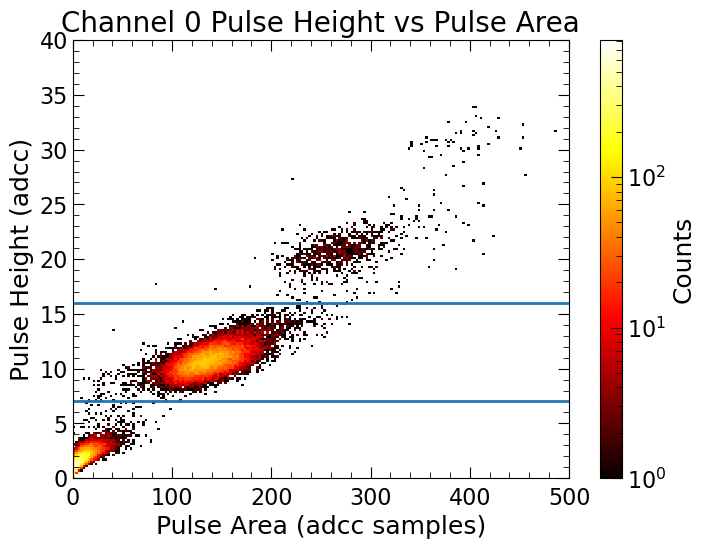

Fitted Amplitude: 566.044
Fitted Mean (μ):  135.595
Fitted Sigma (σ): 0.153


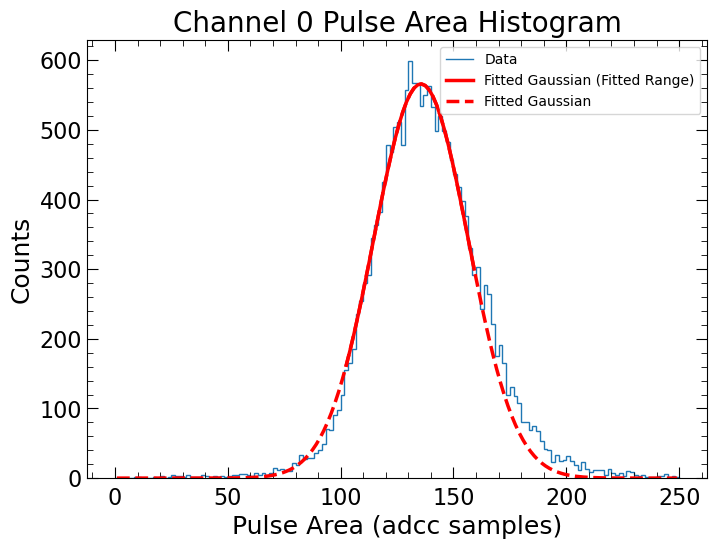

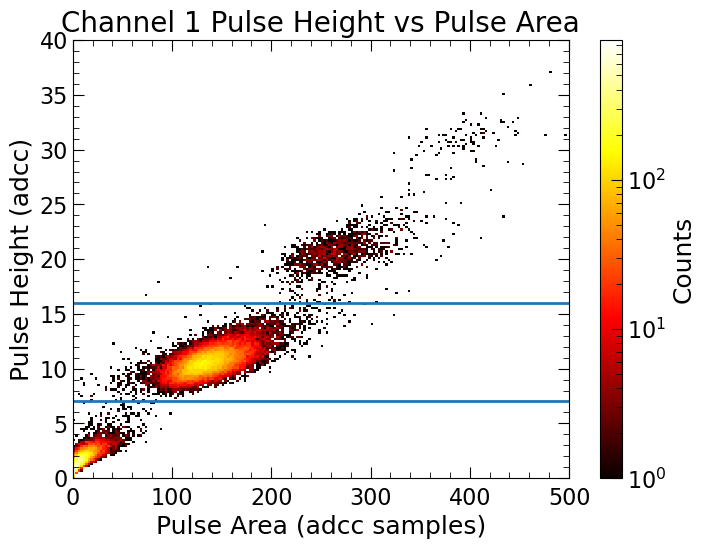

Fitted Amplitude: 888.810
Fitted Mean (μ):  134.367
Fitted Sigma (σ): 0.121


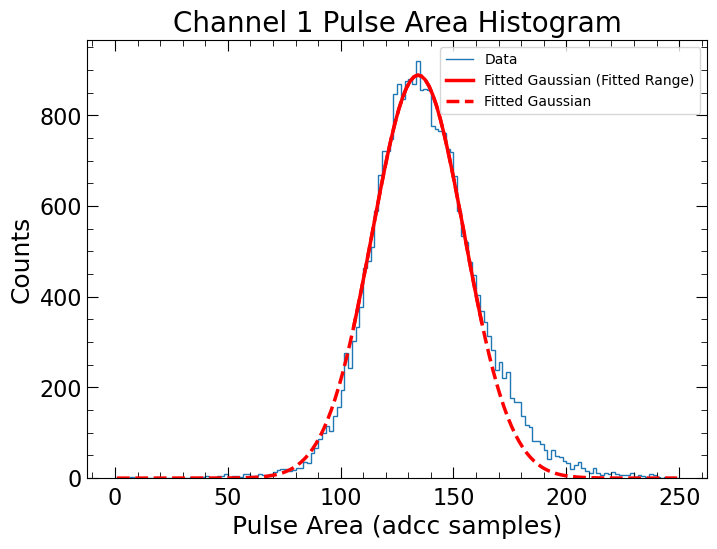

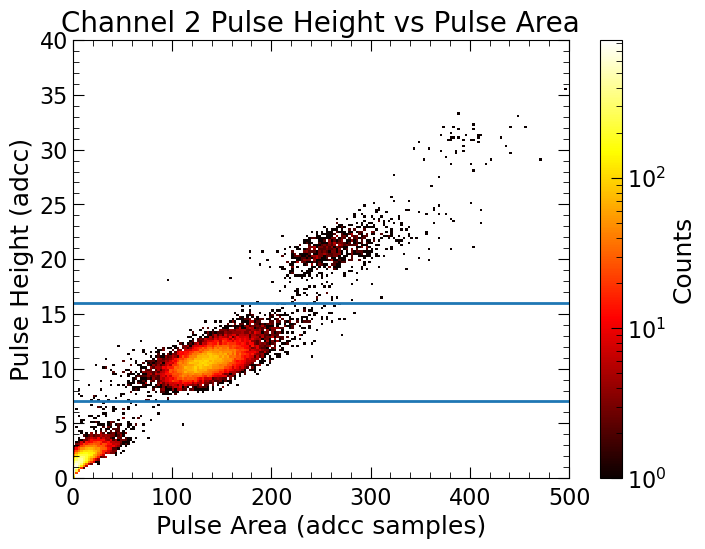

Fitted Amplitude: 607.961
Fitted Mean (μ):  134.070
Fitted Sigma (σ): 0.147


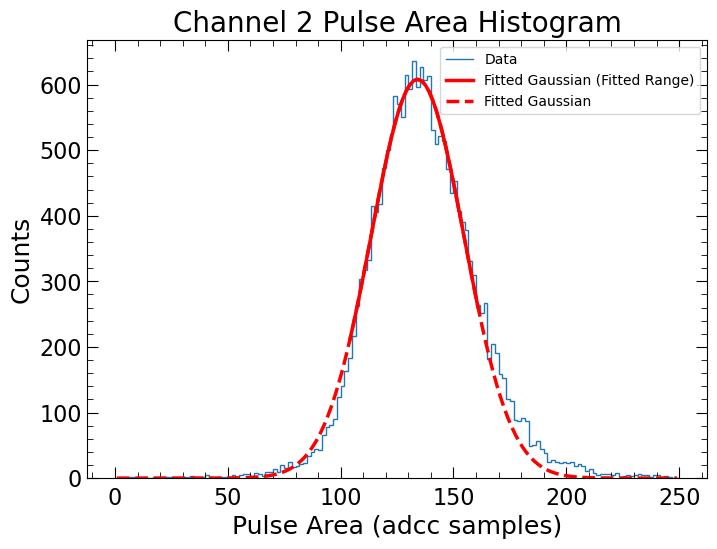

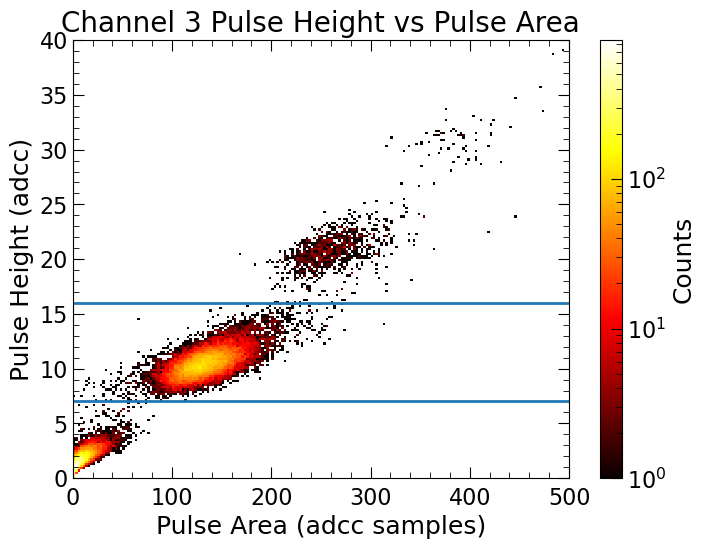

Fitted Amplitude: 725.682
Fitted Mean (μ):  131.756
Fitted Sigma (σ): 0.133


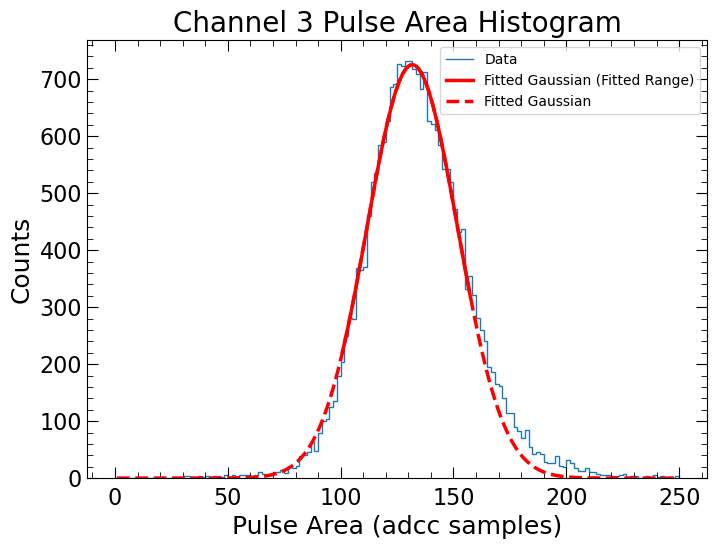

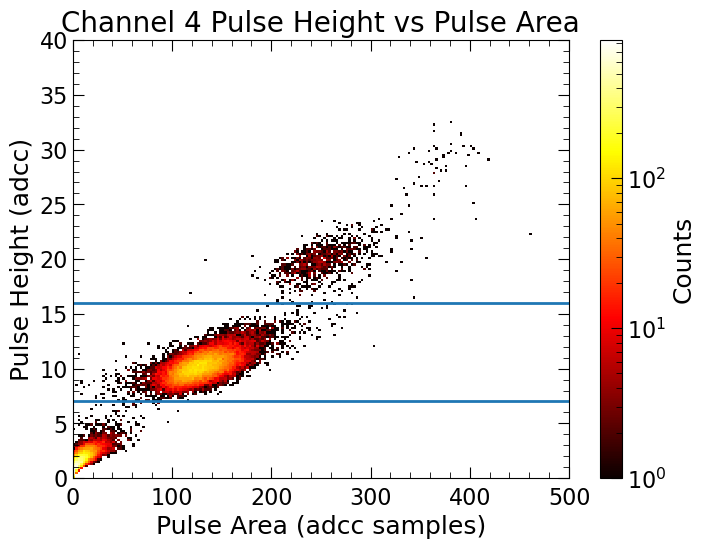

Fitted Amplitude: 743.849
Fitted Mean (μ):  127.917
Fitted Sigma (σ): 0.135


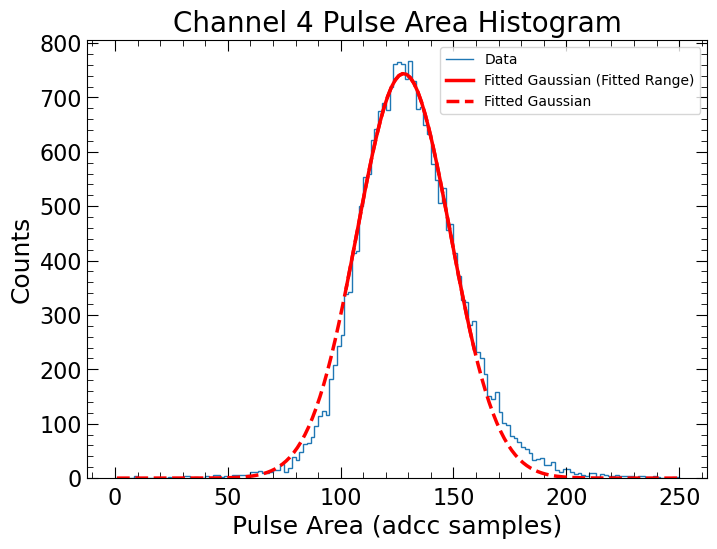

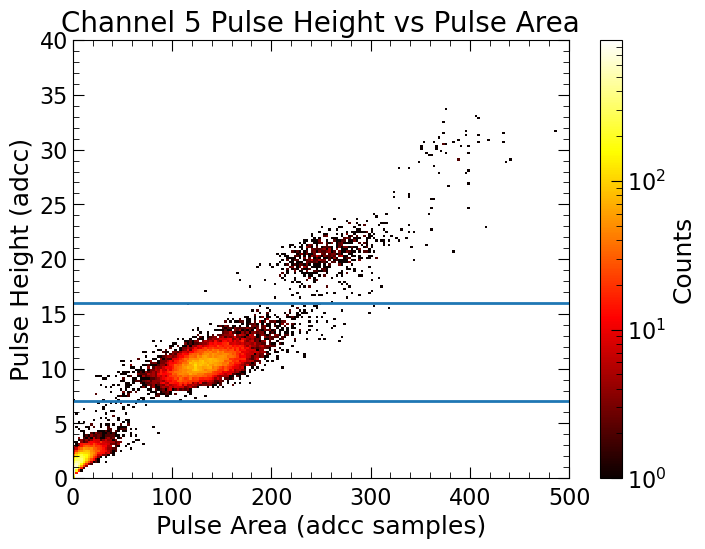

Fitted Amplitude: 533.393
Fitted Mean (μ):  131.007
Fitted Sigma (σ): 0.150


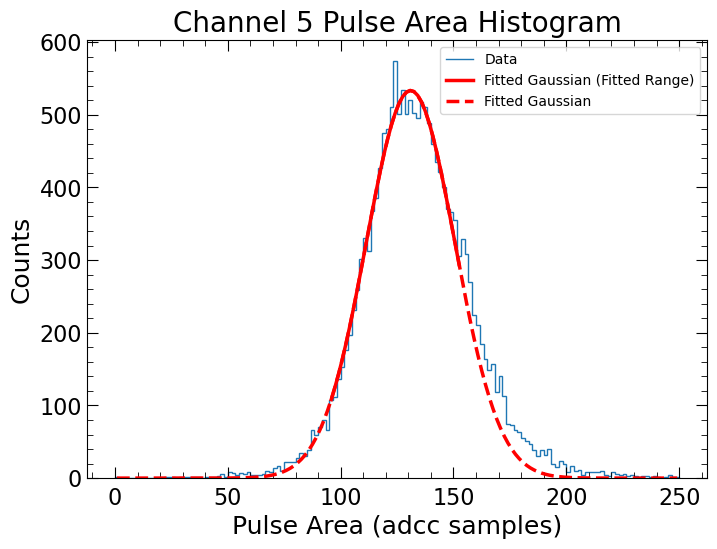

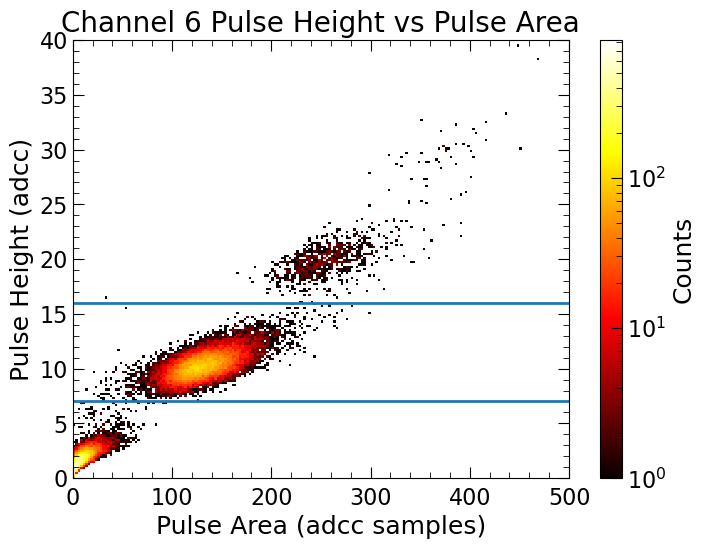

Fitted Amplitude: 626.732
Fitted Mean (μ):  128.967
Fitted Sigma (σ): 0.142


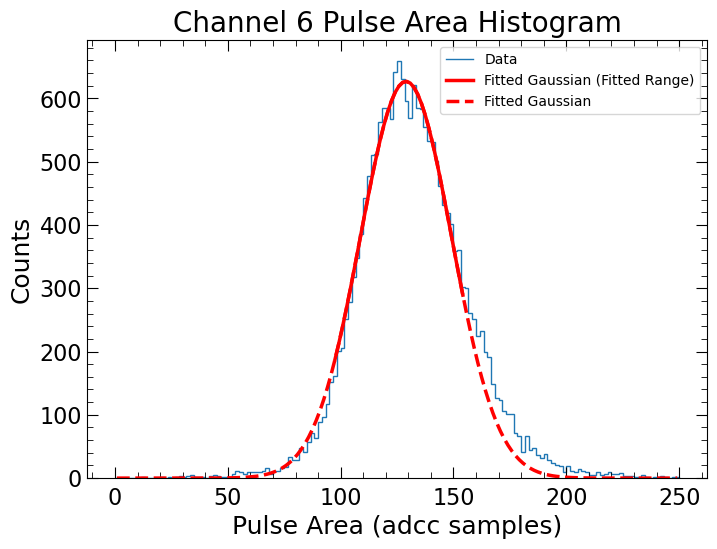

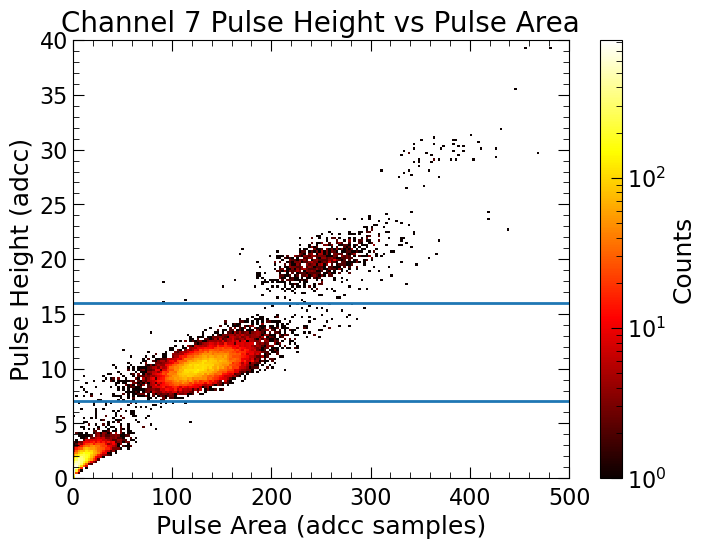

Fitted Amplitude: 715.520
Fitted Mean (μ):  128.451
Fitted Sigma (σ): 0.142


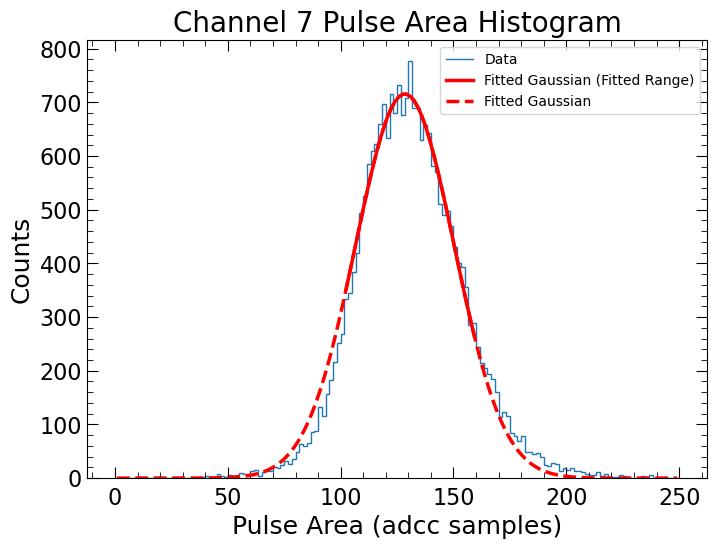

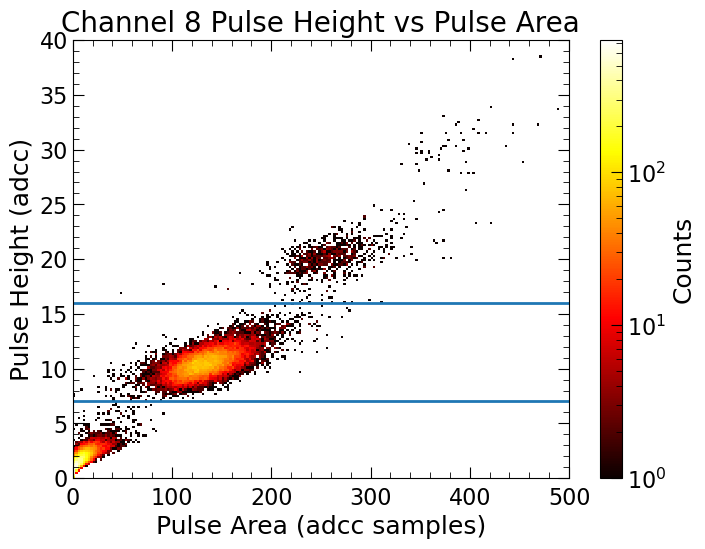

Fitted Amplitude: 532.158
Fitted Mean (μ):  131.459
Fitted Sigma (σ): 0.163


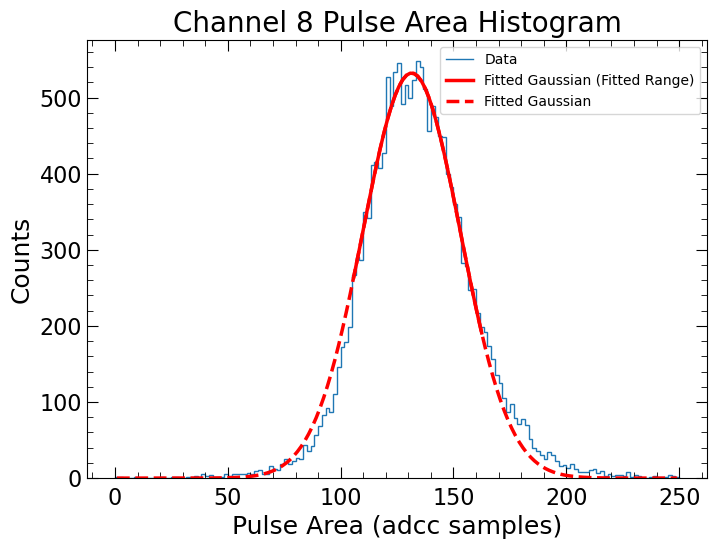

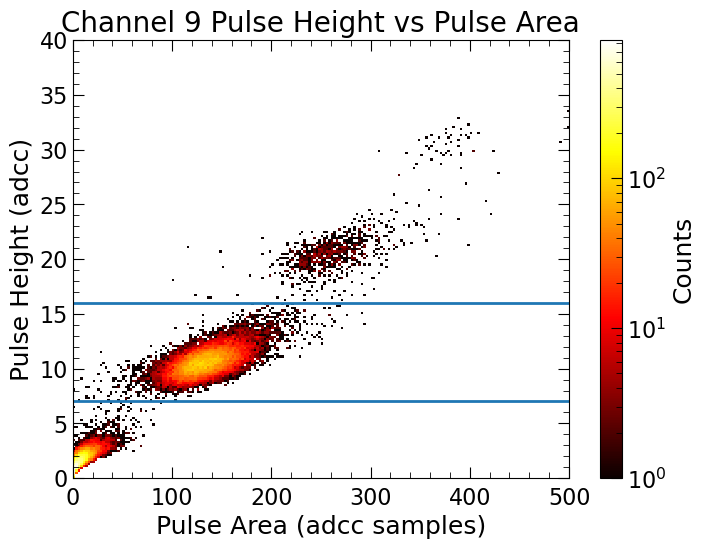

Fitted Amplitude: 620.490
Fitted Mean (μ):  132.317
Fitted Sigma (σ): 0.145


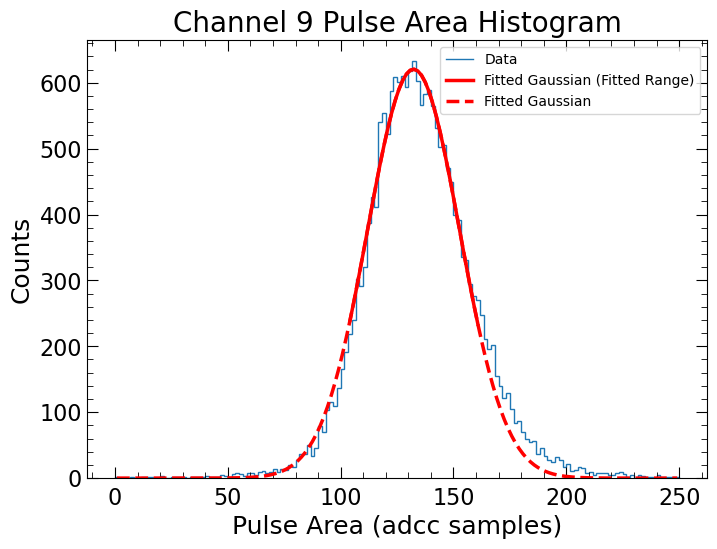

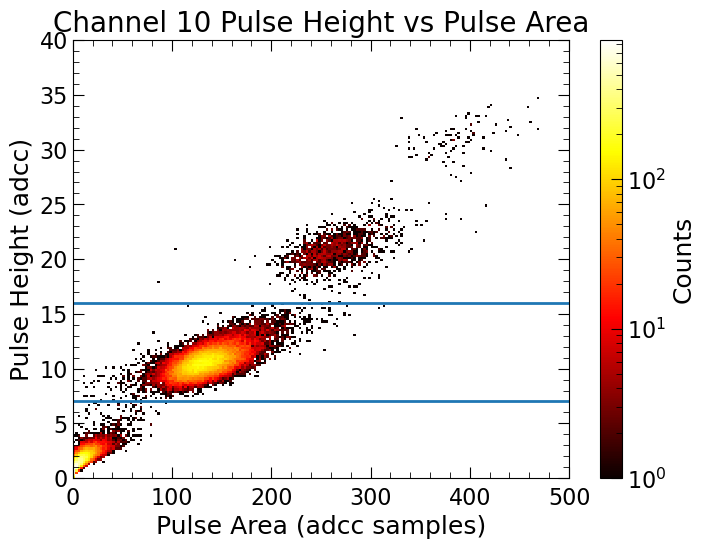

Fitted Amplitude: 1033.968
Fitted Mean (μ):  132.381
Fitted Sigma (σ): 0.109


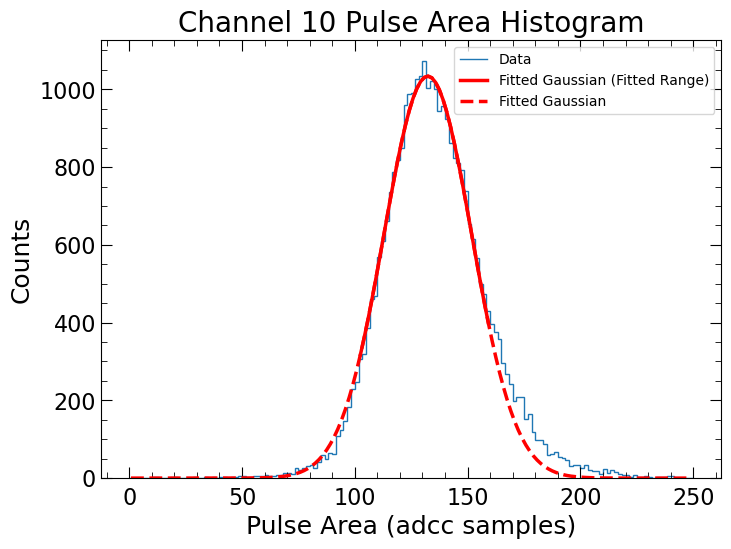

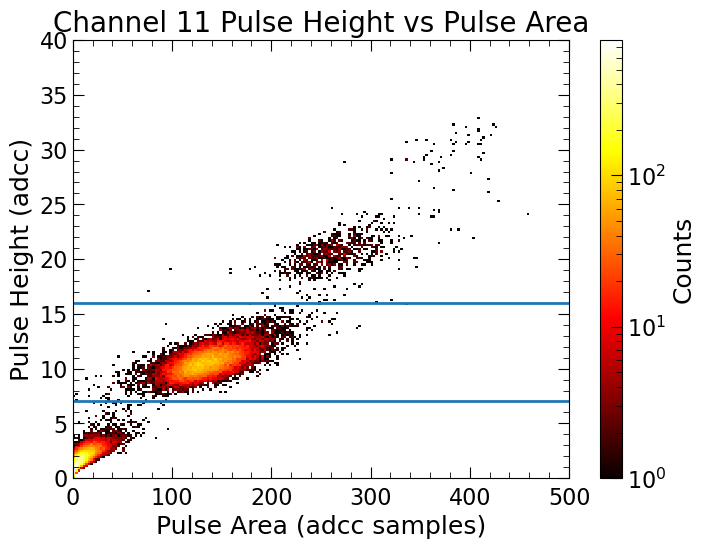

Fitted Amplitude: 557.150
Fitted Mean (μ):  133.428
Fitted Sigma (σ): 0.154


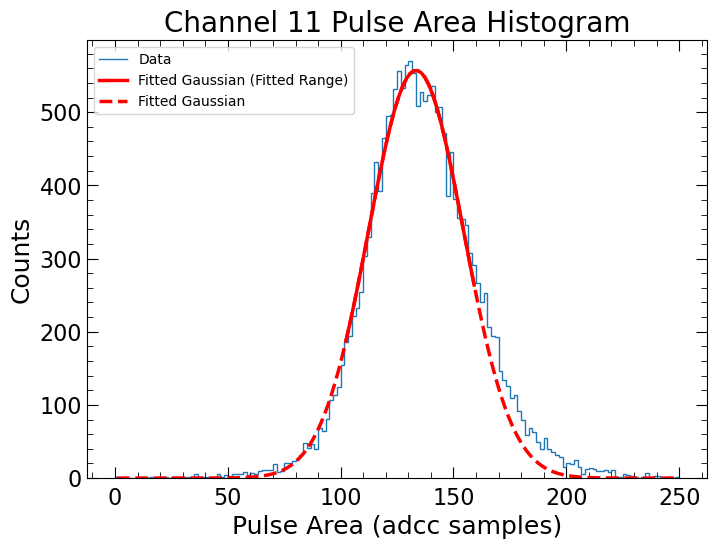

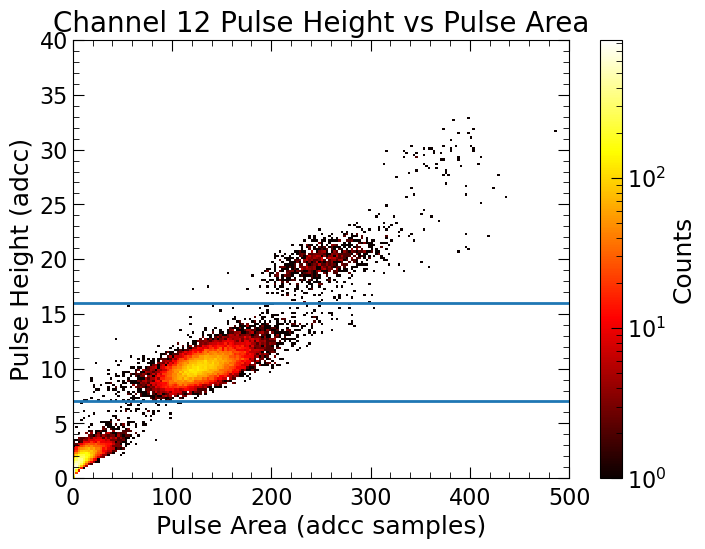

Fitted Amplitude: 716.113
Fitted Mean (μ):  128.152
Fitted Sigma (σ): 0.144


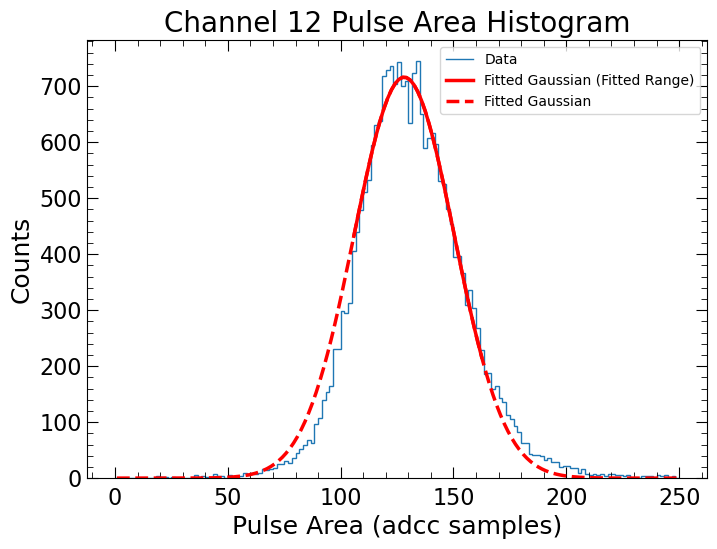

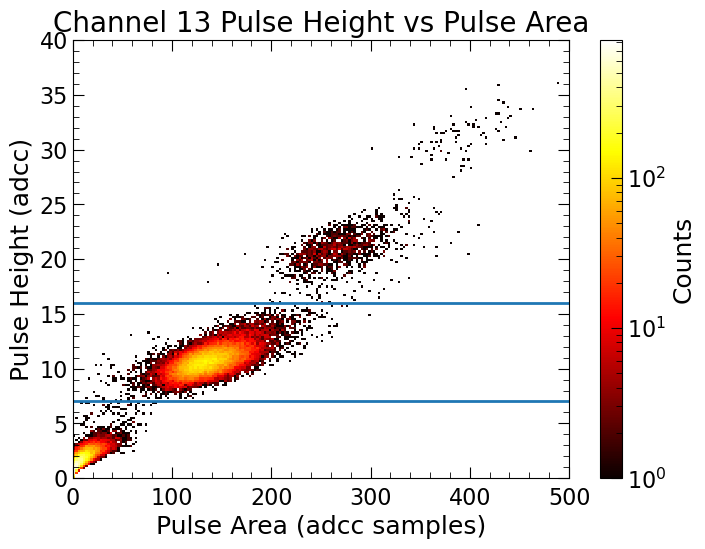

Fitted Amplitude: 845.490
Fitted Mean (μ):  134.000
Fitted Sigma (σ): 0.126


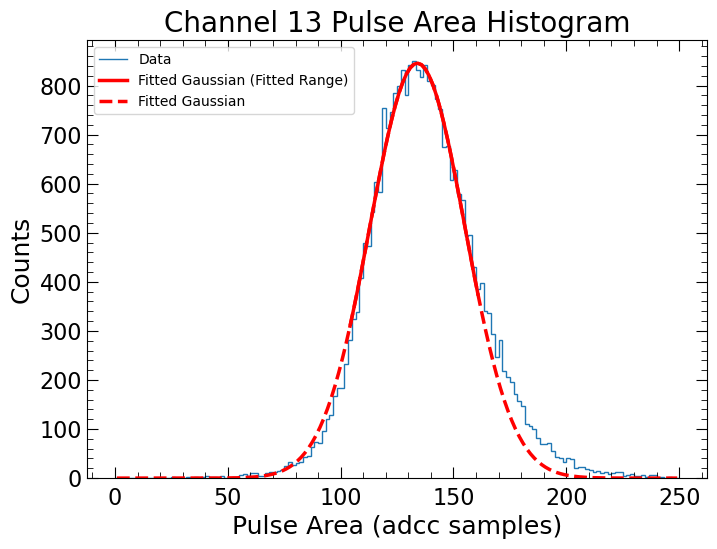

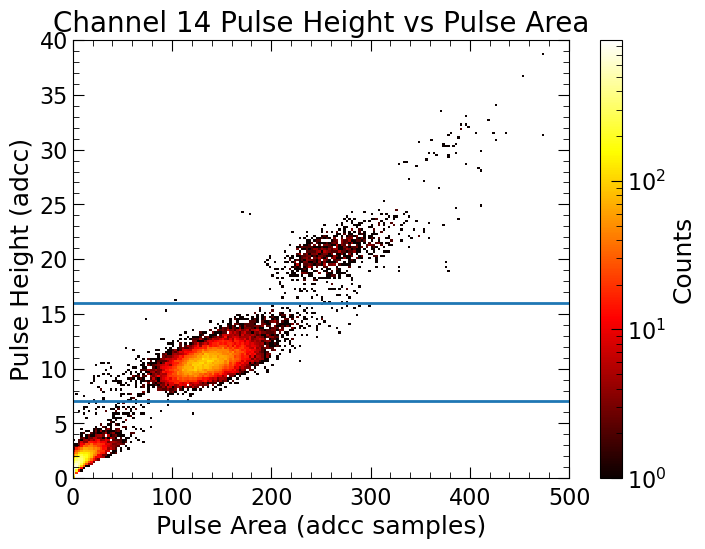

Fitted Amplitude: 627.418
Fitted Mean (μ):  133.767
Fitted Sigma (σ): 0.145


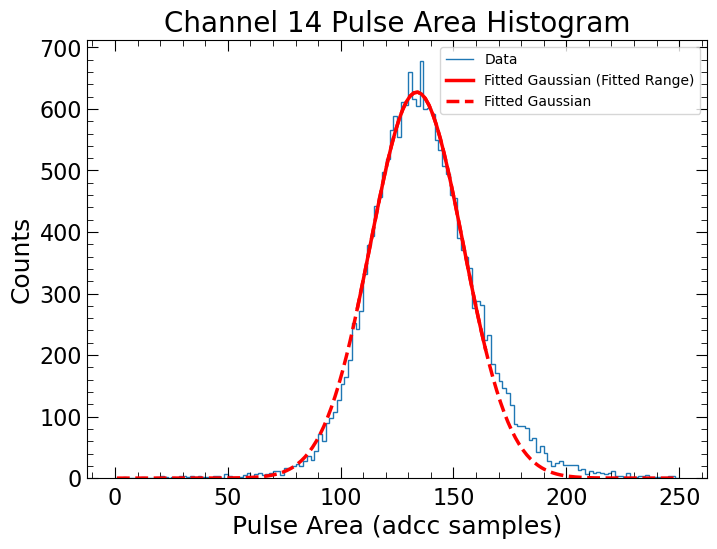

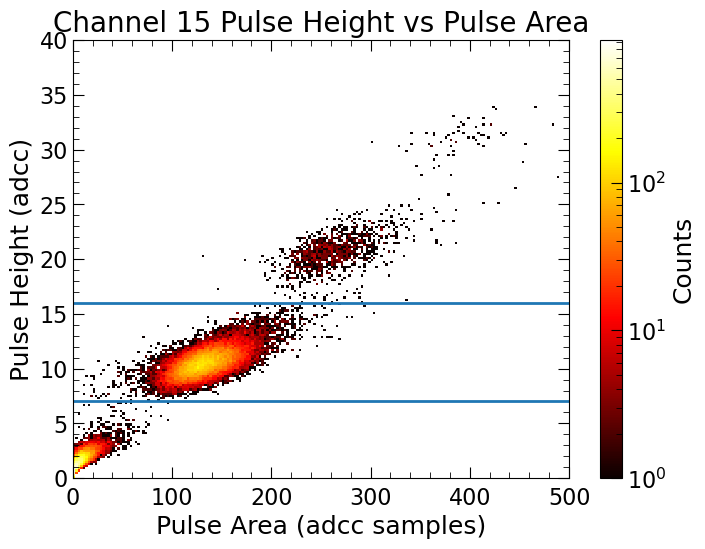

Fitted Amplitude: 793.479
Fitted Mean (μ):  130.944
Fitted Sigma (σ): 0.122


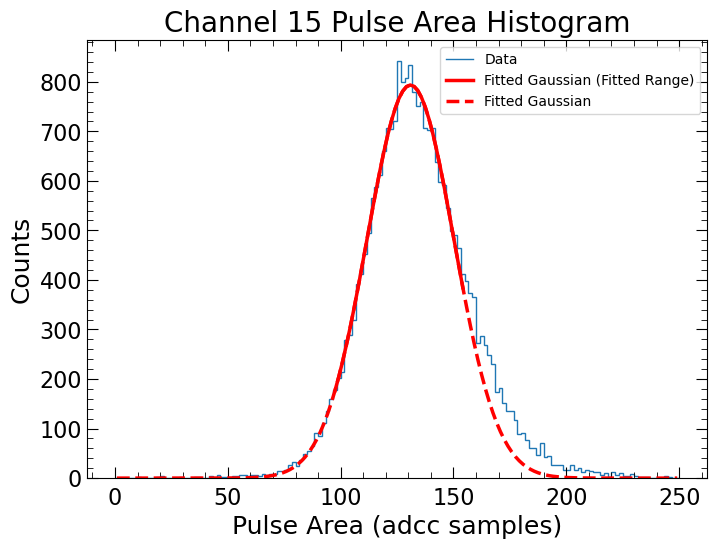

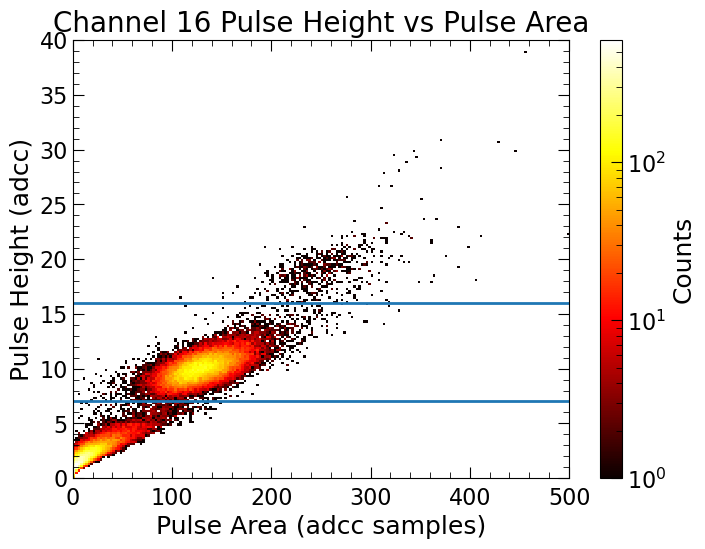

Fitted Amplitude: 883.852
Fitted Mean (μ):  127.539
Fitted Sigma (σ): 0.122


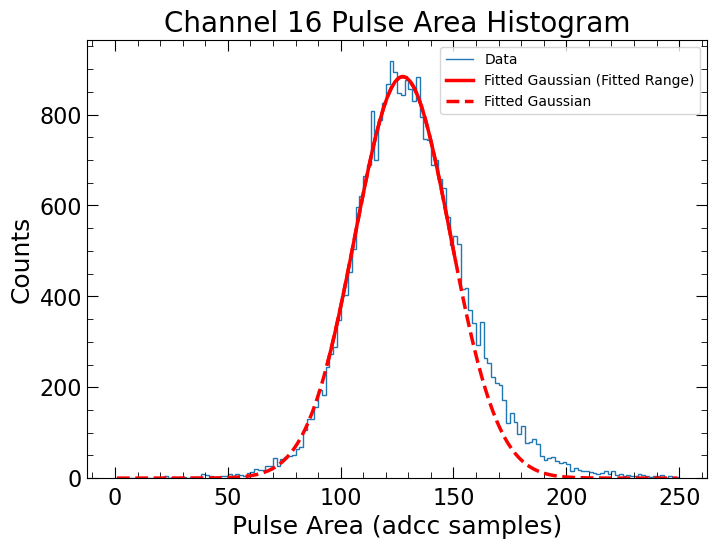

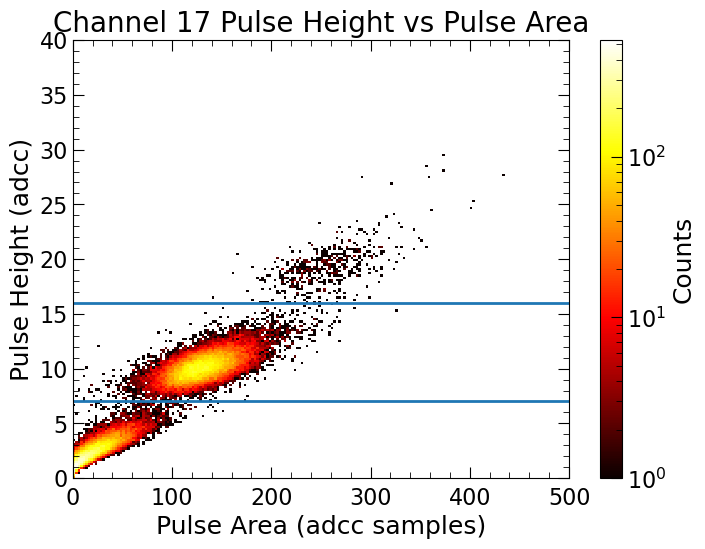

Fitted Amplitude: 874.400
Fitted Mean (μ):  128.687
Fitted Sigma (σ): 0.123


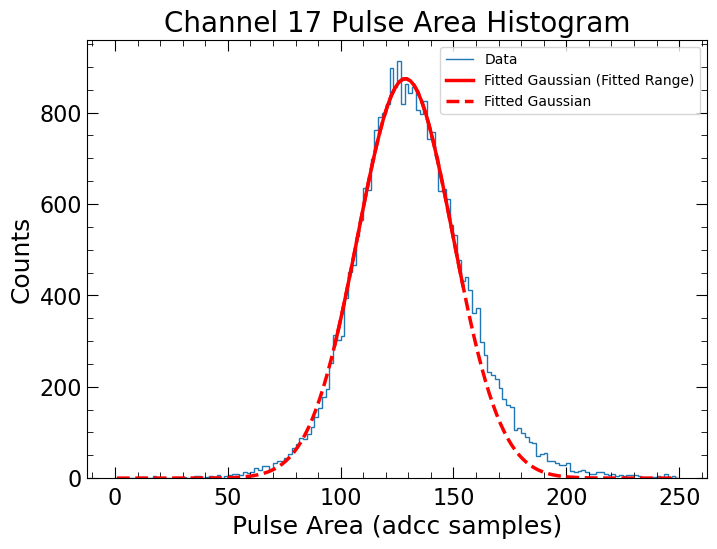

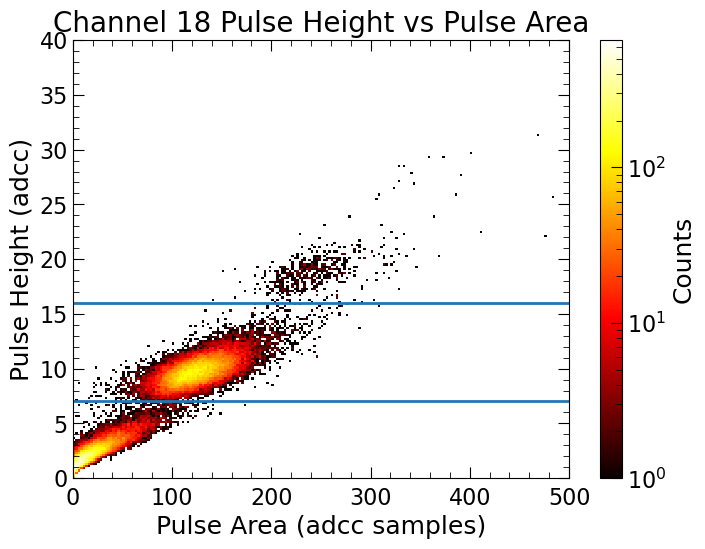

Fitted Amplitude: 787.493
Fitted Mean (μ):  122.590
Fitted Sigma (σ): 0.128


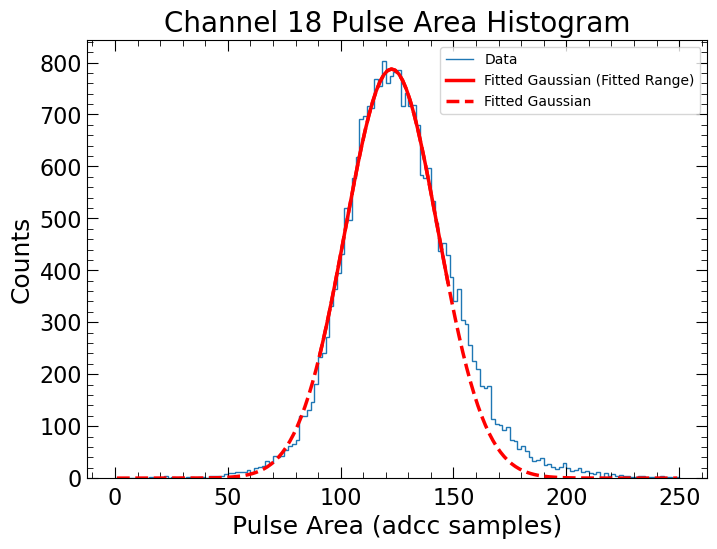

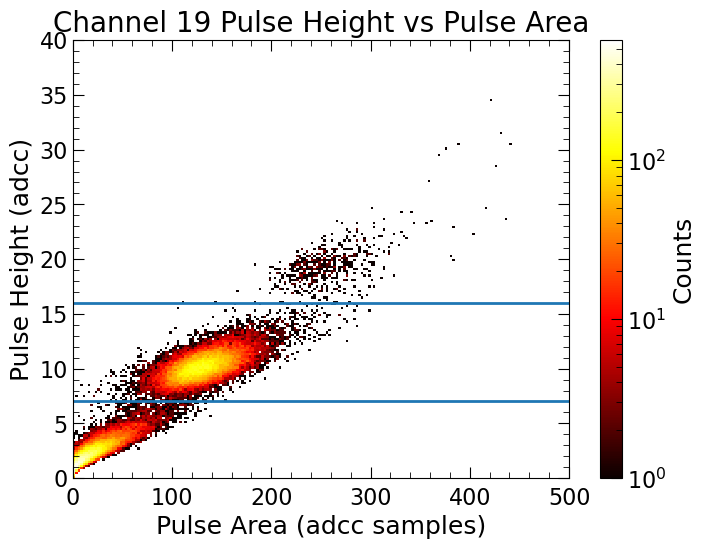

Fitted Amplitude: 868.067
Fitted Mean (μ):  128.948
Fitted Sigma (σ): 0.127


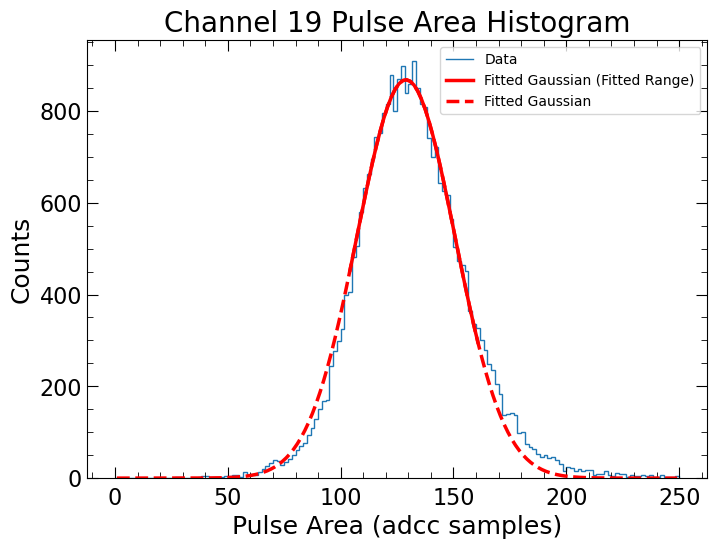

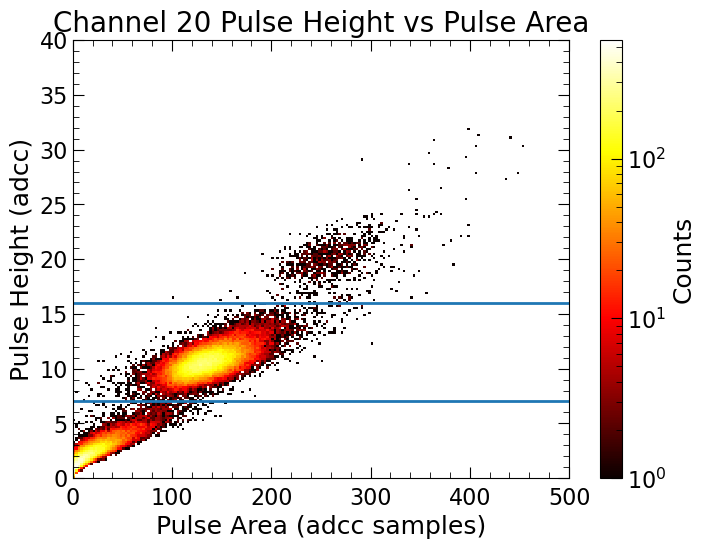

Fitted Amplitude: 1496.198
Fitted Mean (μ):  133.002
Fitted Sigma (σ): 0.091


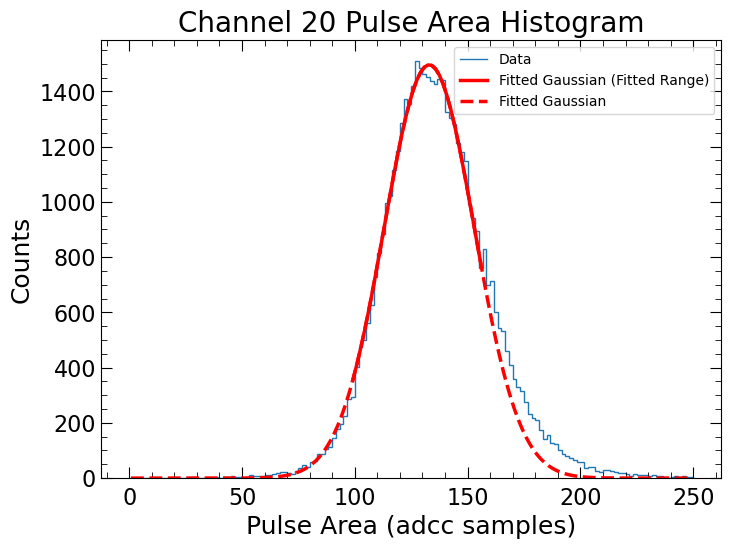

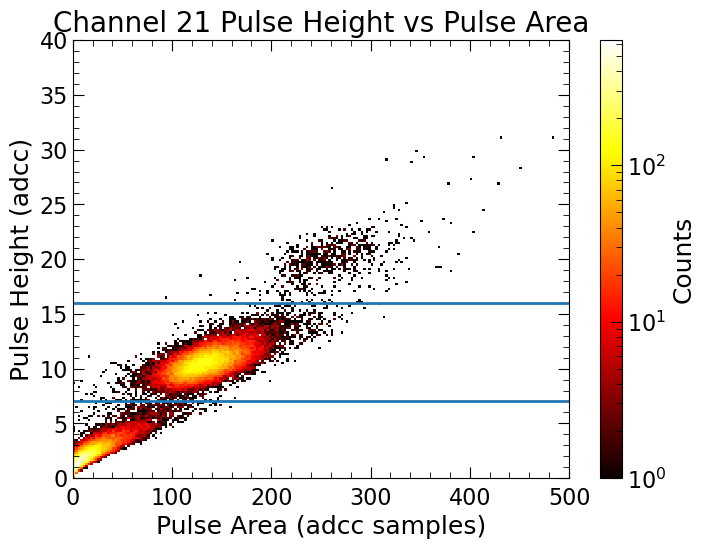

Fitted Amplitude: 951.968
Fitted Mean (μ):  131.989
Fitted Sigma (σ): 0.117


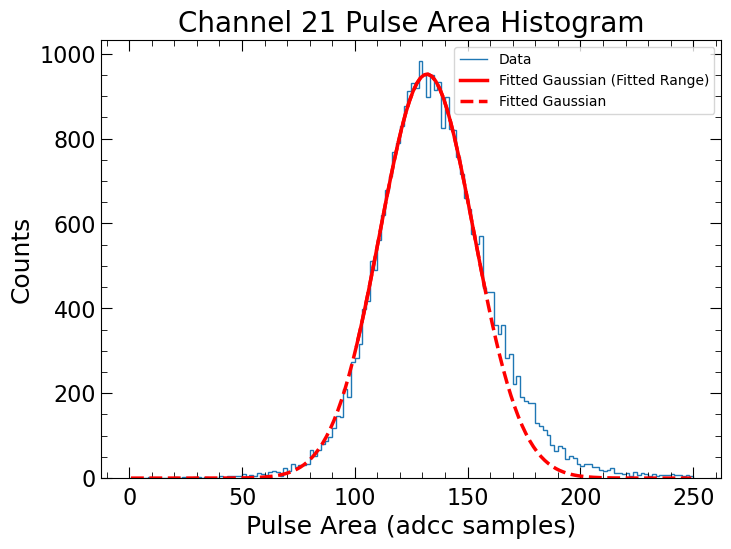

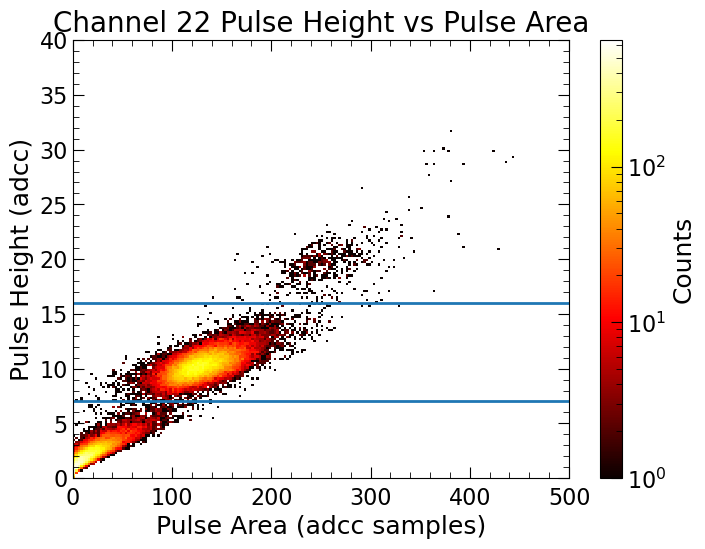

Fitted Amplitude: 1006.830
Fitted Mean (μ):  127.683
Fitted Sigma (σ): 0.113


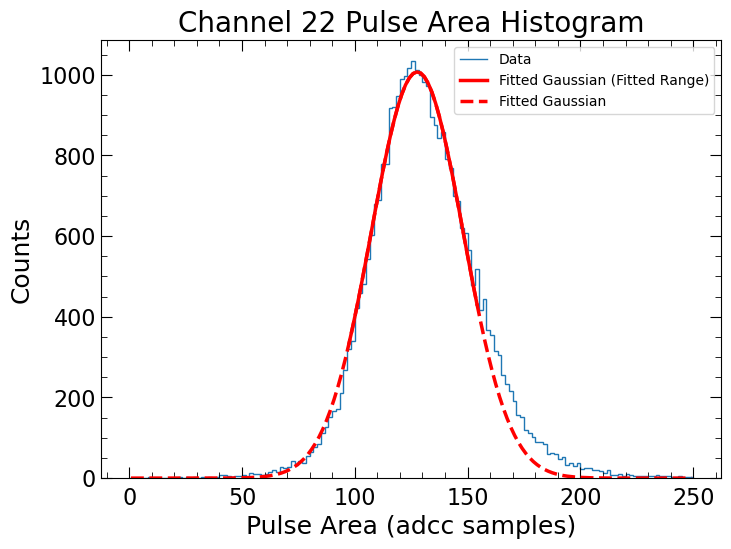

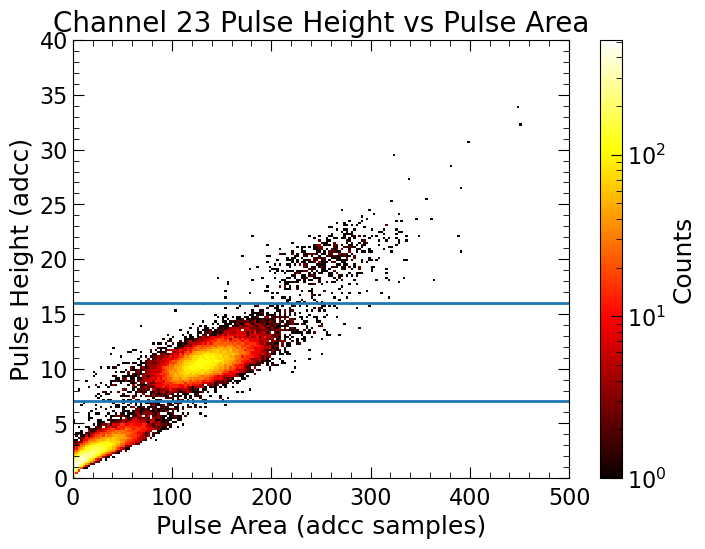

Fitted Amplitude: 794.198
Fitted Mean (μ):  132.672
Fitted Sigma (σ): 0.131


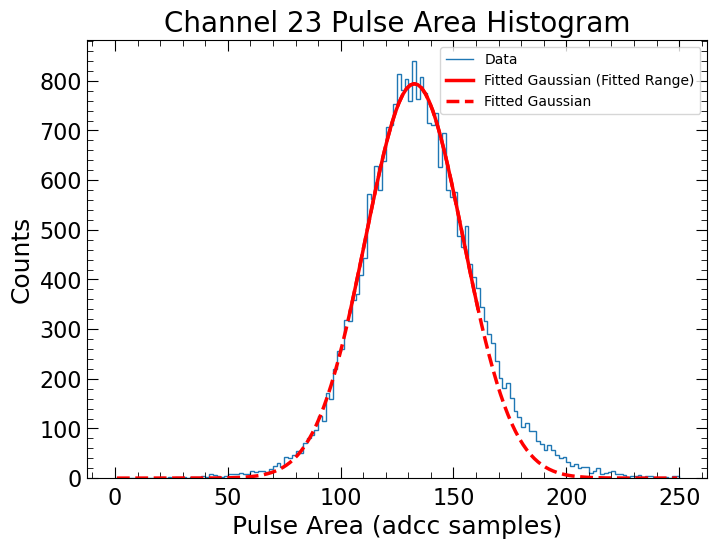

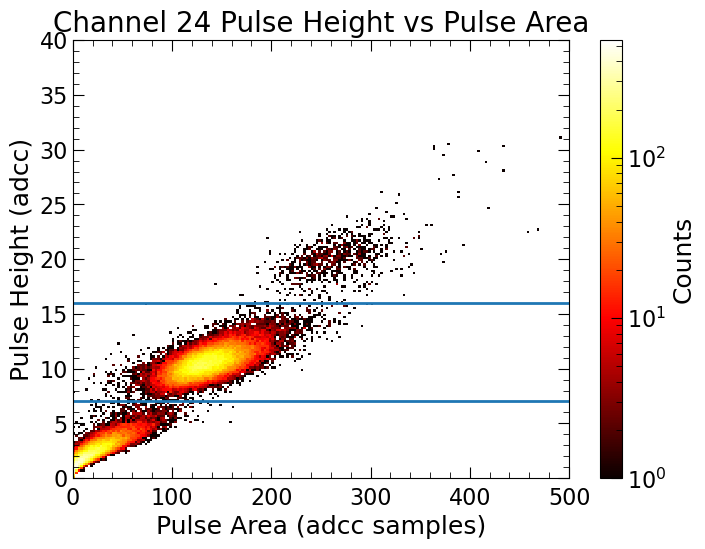

Fitted Amplitude: 1164.642
Fitted Mean (μ):  133.546
Fitted Sigma (σ): 0.107


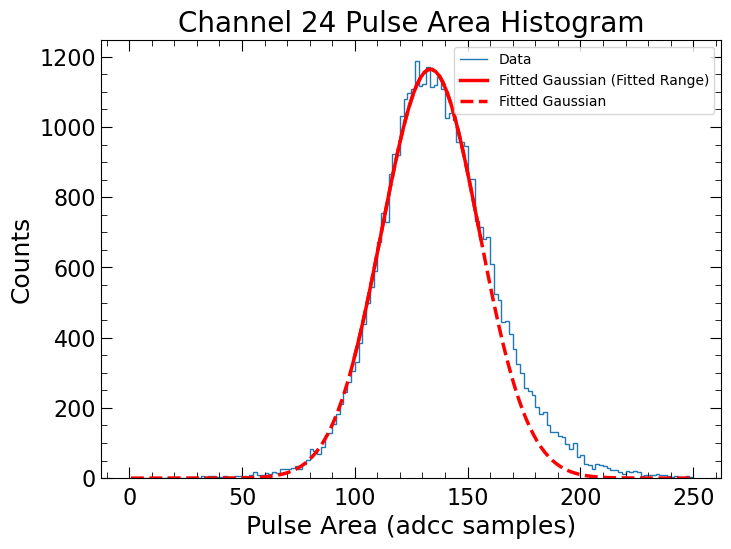

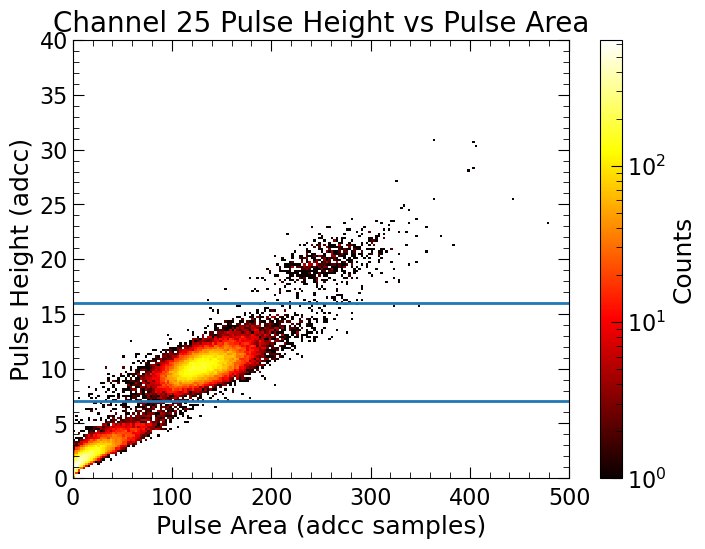

Fitted Amplitude: 1085.532
Fitted Mean (μ):  129.418
Fitted Sigma (σ): 0.110


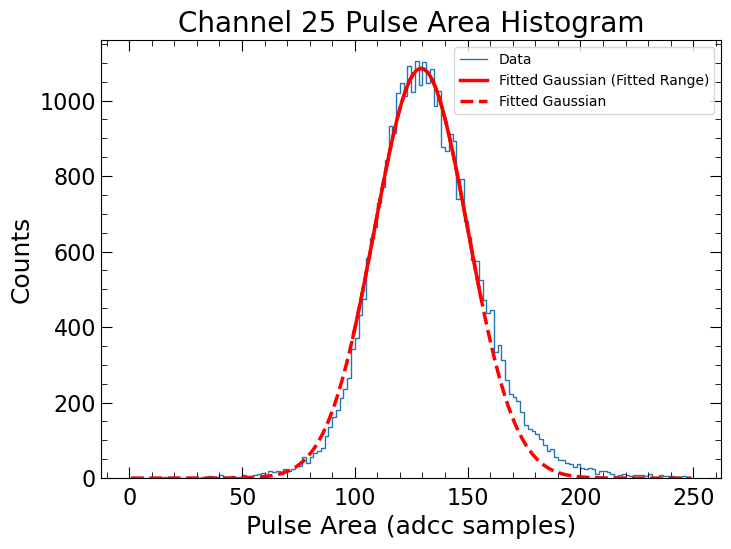

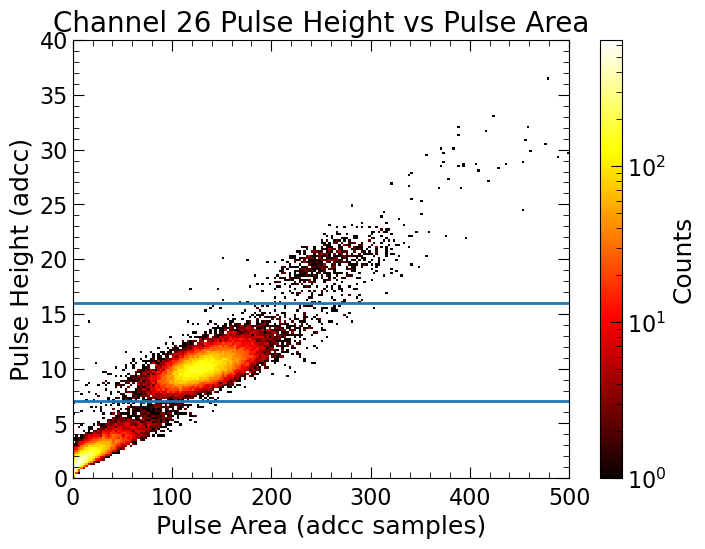

Fitted Amplitude: 1045.467
Fitted Mean (μ):  128.894
Fitted Sigma (σ): 0.114


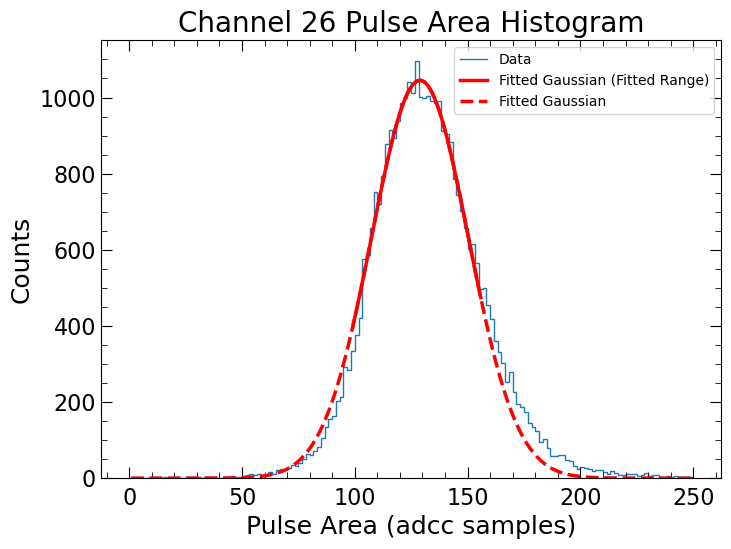

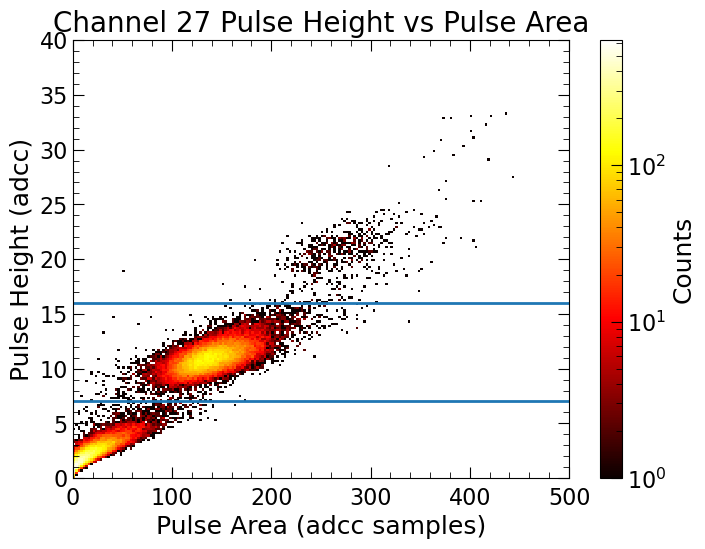

Fitted Amplitude: 812.046
Fitted Mean (μ):  137.044
Fitted Sigma (σ): 0.130


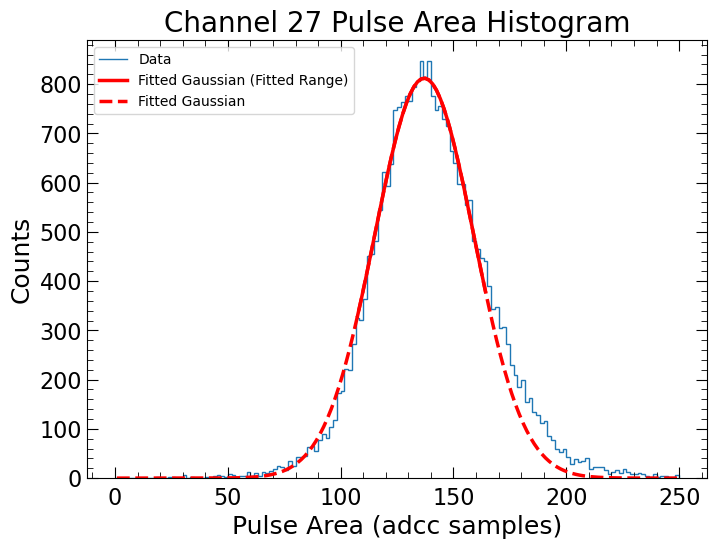

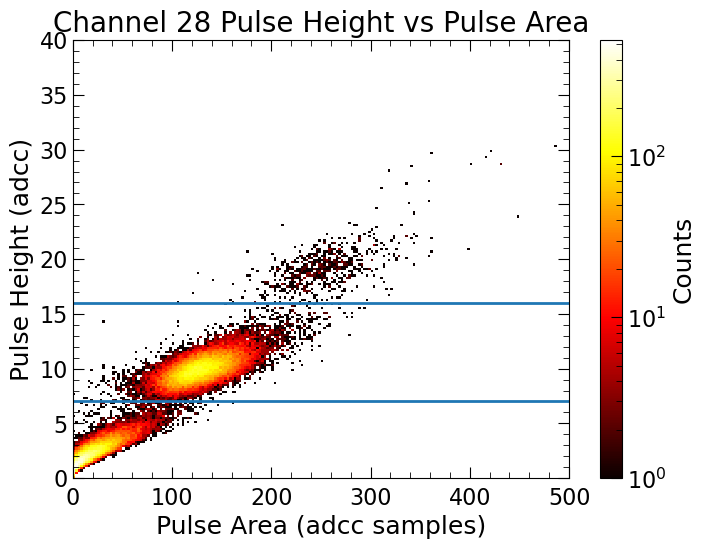

Fitted Amplitude: 891.557
Fitted Mean (μ):  127.180
Fitted Sigma (σ): 0.124


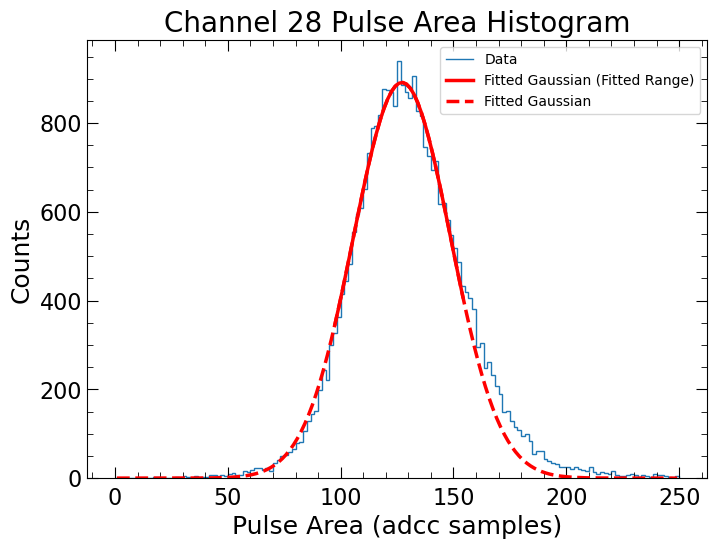

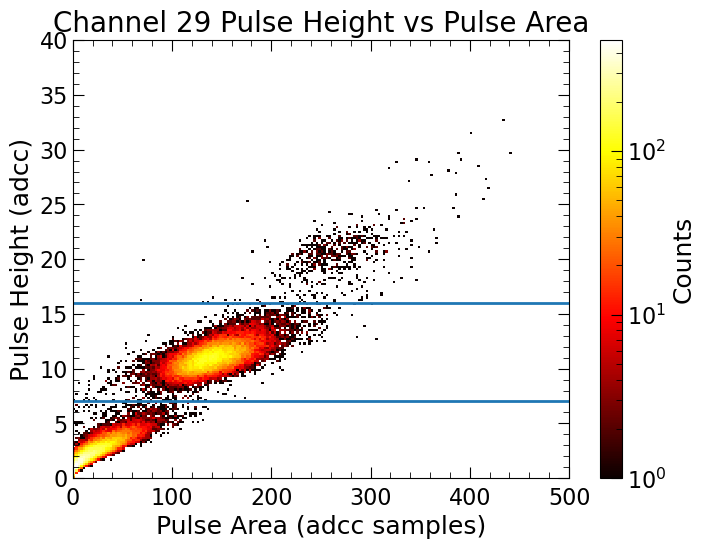

Fitted Amplitude: 783.665
Fitted Mean (μ):  138.941
Fitted Sigma (σ): 0.138


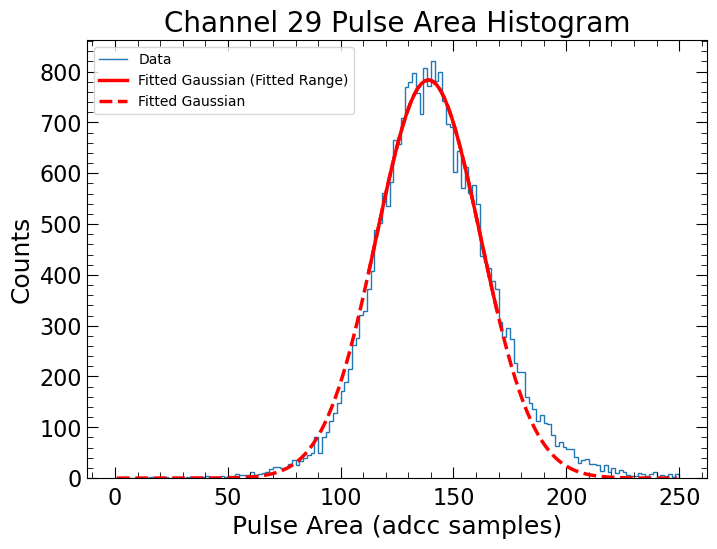

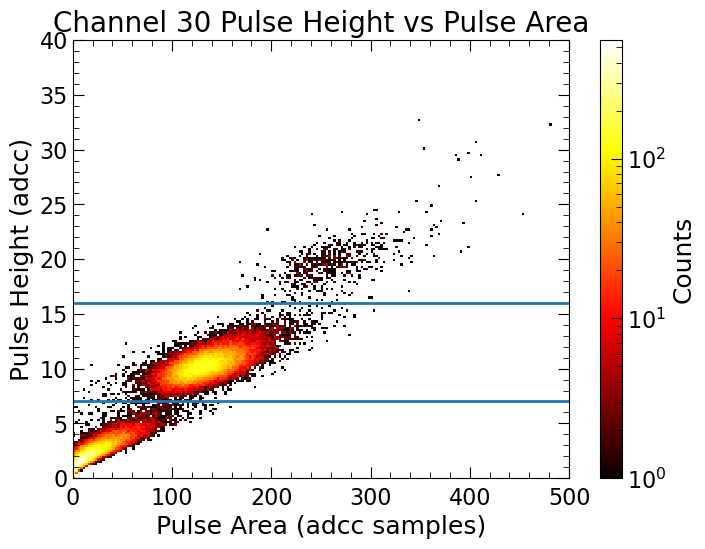

Fitted Amplitude: 928.604
Fitted Mean (μ):  131.321
Fitted Sigma (σ): 0.125


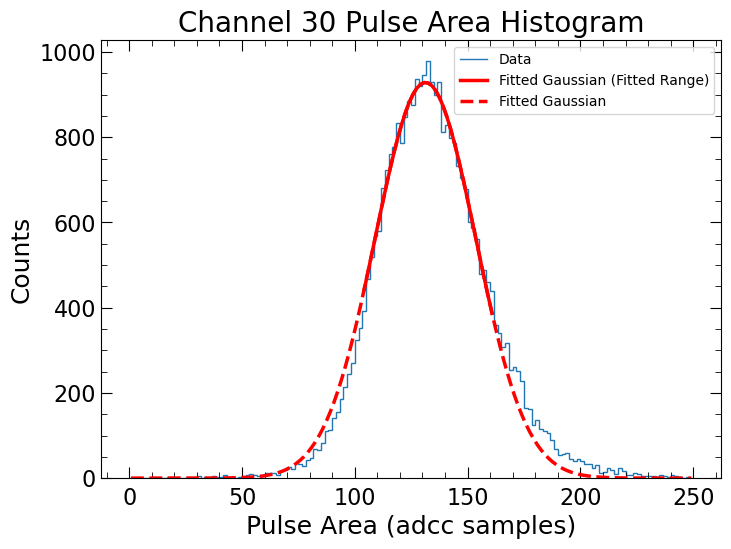

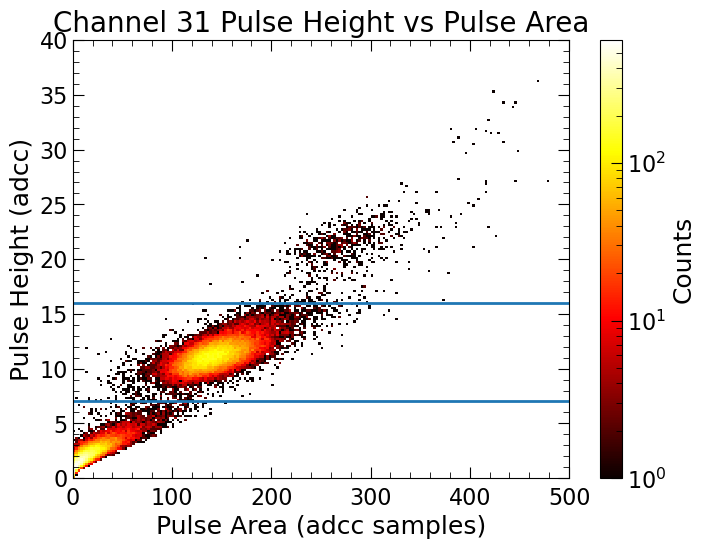

Fitted Amplitude: 917.240
Fitted Mean (μ):  140.795
Fitted Sigma (σ): 0.123


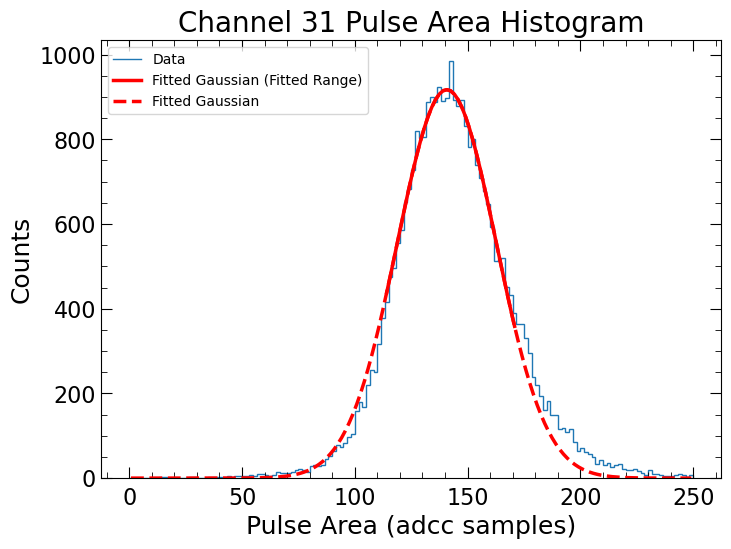

In [15]:
for i in range(32):
    spe_area_ch[i], spe_width_ch[i] = get_spe_stats(7,16,i)

In [17]:
with open("SiPMgains_amplifier_50V_02.txt", "w", encoding="utf-8") as file:
    file.write("# From first 50 files of " + dataset_labels[0] + "\n")
    file.write("# SiPM channel, spe area [adcc*samples], area uncert [adcc*samples]\n")
    for i in range(32):
        file.write(str(i)+" "+str(spe_area_ch[i])+" "+str(spe_width_ch[i]))
        file.write("\n")

In [29]:
# Values from SiPMgains_2026-05-08-1053.txt

past_spe = np.array([
    104.30889753238147,
    108.14717052481762,
    106.43129031271255,
    107.34682964797958,
    128.1600178133758,
    129.47910328856057,
    125.44025011004635,
    125.95235094049025,
    127.53663421285421,
    126.38528747574829,
    130.87103063569006,
    129.23338023298086,
    126.14832219414473,
    132.3756534430131,
    127.35505672217403,
    132.71492678980024,
    98.48621861687795,
    100.52861453837968,
    96.32957029886467,
    100.60810751580655,
    129.00990371109162,
    127.98694773990691,
    127.59232449436507,
    131.53238016685432,
    131.4270840285182,
    130.2989718516448,
    130.6312702055748,
    133.6870313647257,
    129.65374550598133,
    127.22968271623657,
    129.96053557887015,
    136.40256139942304
])

past_spe_width = np.array([
    0.2313616673376126,
    0.2328132985957945,
    0.22144614154735373,
    0.22275701448183116,
    0.20404523065785687,
    0.20165320479840593,
    0.19146949788411277,
    0.2105611610317878,
    0.1895070525373377,
    0.186930027608339,
    0.18473273026976733,
    0.1926807039419656,
    0.2030557212357445,
    0.1863979392499719,
    0.19252660922005693,
    0.20075943592191975,
    0.24373203055532036,
    0.23270759507651176,
    0.2321655828697811,
    0.23801313171224703,
    0.1951373789298493,
    0.20156256881454382,
    0.1989500655226207,
    0.21057515980510189,
    0.19759070544534488,
    0.18914141014692643,
    0.19411660300027245,
    0.20089592586314428,
    0.21361511654355675,
    0.20686548480040803,
    0.20068517619164727,
    0.2019971083080115
])

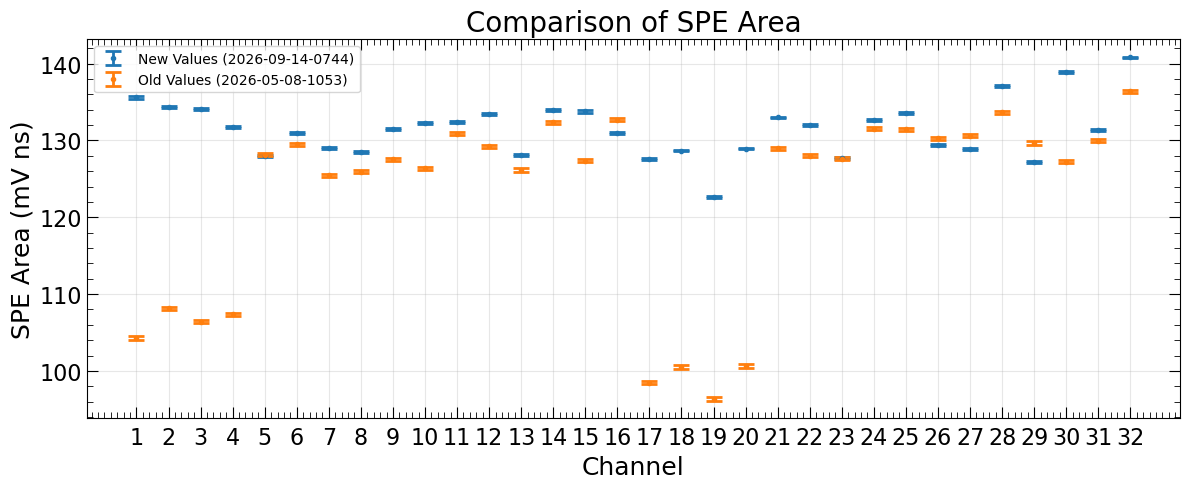

In [28]:

x = np.arange(32)+1

plt.figure(figsize=(12, 5))

# Slightly offset the points so they don't overlap
offset = 0.0

plt.errorbar(
    x - offset,
    spe_area_ch,
    fmt='o',
    markersize=3,      # smaller point
    capsize=6,         # wider error-bar caps
    capthick=2,        # thicker caps
    elinewidth=2,      # thicker error bars
    yerr=spe_width_ch,
    label='New Values (2026-09-14-0744)'
)

plt.errorbar(
    x + offset,
    past_spe,
    fmt='o',
    markersize=3,      # smaller point
    capsize=6,         # wider error-bar caps
    capthick=2,        # thicker caps
    elinewidth=2,      # thicker error bars
    yerr=past_spe_width,
    label='Old Values (2026-05-08-1053)'
)

plt.xlabel('Channel')
plt.ylabel('SPE Area (mV ns)')
plt.title('Comparison of SPE Area')
plt.xticks(x)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()